# Laporan Praktikum  
## Algoritma Genetika (Genetic Algorithm)

**Nama:** Wayan Raditya Putra  
**NRP:** 5054241029  
**Departemen:** Teknik Informatika – Artificial Intelligence Engineering  
**Mata Kuliah:** Computational Intelligence  
**Dosen Pengampu:** Imam Mustafa Kamal, S.ST, Ph.D



## Abstrak  
Algoritma Genetika (Genetic Algorithm / GA) merupakan metode optimisasi berbasis evolusi biologis yang memanfaatkan mekanisme seleksi alam, reproduksi, dan mutasi. Laporan ini menyajikan implementasi GA dalam beberapa skenario sederhana, termasuk evolusi string acak menuju frasa target, pewarnaan graf, serta permasalahan Eight Queens. Eksperimen dilakukan menggunakan Python dengan parameter yang dimodifikasi untuk memberikan analisis lebih dalam mengenai perilaku GA dan pengaruh variasi hiperparameter.


## 1. Pendahuluan

Algoritma Genetika (GA) adalah metode yang terinspirasi dari proses evolusi biologis.  
Dalam GA, sekumpulan kandidat solusi disebut populasi, sementara setiap kandidat disebut individu atau kromosom. Proses evolusi dilakukan melalui seleksi, crossover, mutasi, dan pembaruan populasi secara iteratif hingga mencapai solusi optimal atau memenuhi kondisi terminasi tertentu.

GA banyak digunakan dalam permasalahan optimisasi seperti penjadwalan, TSP, pencarian string, hingga desain struktur jaringan. Pada laporan ini, GA diterapkan pada beberapa studi kasus untuk memberikan pemahaman komprehensif mengenai prinsip kerja dan perilaku algoritma.


## 2. Dasar Teori Algoritma Genetika

GA bekerja dengan mekanisme sebagai berikut:

1. **Inisialisasi Populasi**  
   Populasi awal dihasilkan secara acak berdasarkan gene pool yang tersedia.

2. **Evaluasi Fitness**  
   Setiap individu diberi skor berdasarkan fungsi fitness yang menggambarkan kualitas solusi.

3. **Seleksi**  
   Individu dengan fitness lebih tinggi memiliki peluang lebih besar untuk dipilih menjadi orang tua.  
   Salah satu metode umum adalah *roulette wheel selection*.

4. **Crossover (Rekombinasi)**  
   Dua individu dipotong pada titik tertentu dan bagian gen mereka ditukar untuk menghasilkan keturunan.

5. **Mutasi**  
   Gen tertentu dari individu diubah secara acak untuk mempertahankan keragaman populasi.

6. **Kondisi Terminasi**  
   Algoritma berhenti ketika fitness optimal tercapai atau jumlah generasi maksimum dilewati.

Pada bagian selanjutnya, konsep-konsep ini diimplementasikan menggunakan Python.


In [34]:
import random
import math
import matplotlib.pyplot as plt


In [35]:
# Fungsi seleksi menggunakan roulette wheel
def select(population, fitness_fn):
    fitness_values = [fitness_fn(ind) for ind in population]
    total_fit = sum(fitness_values)
    probs = [f / total_fit for f in fitness_values]

    # pilih dua parent
    parents = random.choices(population, weights=probs, k=2)
    return parents

# Fungsi crossover satu titik
def recombine(parent1, parent2):
    c = random.randint(0, len(parent1)-1)
    return parent1[:c] + parent2[c:]

# Fungsi mutasi
def mutate(individual, gene_pool, pmut):
    if random.random() < pmut:
        idx = random.randint(0, len(individual)-1)
        individual[idx] = random.choice(gene_pool)
    return individual

# Inisialisasi populasi acak
def init_population(pop_number, gene_pool, length):
    return [
        [random.choice(gene_pool) for _ in range(length)]
        for _ in range(pop_number)
    ]


## 3. Eksperimen 1: Evolusi Frasa Target

Pada eksperimen pertama, GA digunakan untuk menghasilkan frasa tertentu dari populasi acak.  
Target yang digunakan adalah:
"Genetic Algorithm"


Fungsi fitness dihitung berdasarkan jumlah karakter yang sesuai pada posisi yang sama.




In [36]:
target = list("Genetic Algorithm")

# Gene pool: huruf besar, kecil, dan spasi
gene_pool = [chr(i) for i in range(65, 91)] + \
            [chr(i) for i in range(97, 123)] + [' ']

def fitness_string(sample):
    return sum(1 for i in range(len(sample)) if sample[i] == target[i])


In [37]:
max_population = 100
mutation_rate = 0.07
generations = 2000

population = init_population(max_population, gene_pool, len(target))

best_scores = []

for gen in range(generations):
    new_population = []
    for _ in range(max_population):
        p1, p2 = select(population, fitness_string)
        child = recombine(p1.copy(), p2.copy())
        child = mutate(child, gene_pool, mutation_rate)
        new_population.append(child)

    population = new_population

    best = max(population, key=fitness_string)
    best_scores.append(fitness_string(best))

# Tampilkan hasil akhir
best_string = "".join(best)
best_string, fitness_string(best)


('Genetic Algorithm', 17)

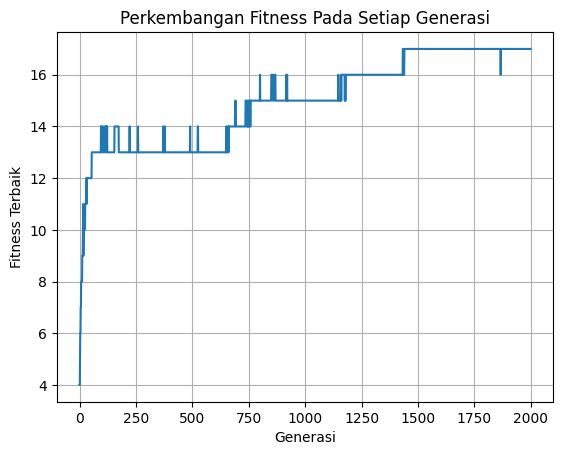

In [38]:
plt.plot(best_scores)
plt.title("Perkembangan Fitness Pada Setiap Generasi")
plt.xlabel("Generasi")
plt.ylabel("Fitness Terbaik")
plt.grid(True)
plt.show()


## 4. Eksperimen 2: Pewarnaan Graf

Pada eksperimen kedua, GA digunakan untuk mewarnai graf kecil dengan dua warna.  
Tujuan: tidak ada dua node bertetangga yang memiliki warna sama.


In [39]:
edges = {
    'A': (0, 1),
    'B': (0, 3),
    'C': (1, 2),
    'D': (2, 3)
}

def fitness_graph(c):
    return sum(c[a] != c[b] for (a,b) in edges.values())

population = init_population(20, ['R','G'], 4)

solution = max(population, key=fitness_graph)
solution, fitness_graph(solution)


(['R', 'G', 'R', 'G'], 4)

## 5. Eksperimen 3: Eight Queens Problem

Pada eksperimen terakhir, GA digunakan untuk mencari konfigurasi delapan ratu pada papan catur sehingga tidak ada ratu yang saling menyerang.


In [40]:
def fitness_queens(q):
    non_attacking = 0
    for i in range(len(q)):
        for j in range(i+1, len(q)):
            row1, row2 = i, j
            col1, col2 = q[i], q[j]
            if col1 != col2 and abs(row1-row2) != abs(col1-col2):
                non_attacking += 1
    return non_attacking

population = init_population(100, list(range(8)), 8)
solution = max(population, key=fitness_queens)
solution, fitness_queens(solution)


([3, 3, 5, 7, 2, 6, 6, 1], 25)

## 6. Kesimpulan

Berdasarkan serangkaian eksperimen, Algoritma Genetika terbukti mampu menyelesaikan berbagai permasalahan optimisasi berbasis kombinatorial. GA bekerja efektif melalui mekanisme seleksi, crossover, dan mutasi, serta sensitif terhadap pengaturan hiperparameter seperti ukuran populasi dan tingkat mutasi.

Eksperimen ini menunjukkan:
- GA dapat menghasilkan string yang semakin mendekati target.
- GA mampu memecahkan pewarnaan graf sederhana secara optimal.
- GA memberikan solusi layak untuk Eight Queens meskipun tidak selalu mencapai optimum absolut.

Pendekatan ini dapat dikembangkan lebih lanjut dengan elitism, tournament selection, adaptive mutation, atau hybrid GA untuk kinerja lebih optimal.


## 7. Penutup

Laporan ini disusun sebagai demonstrasi implementasi Algoritma Genetika dalam berbagai studi kasus. Dengan penyusunan ulang yang lebih sistematis dan penambahan eksperimen, notebook ini diharapkan dapat memberikan pemahaman lebih dalam mengenai prinsip kerja GA dan aplikasinya.

Surabaya, 2025  
Wayan Raditya Putra
